### Disciplina de Análise de Dados    
### Curso de Gestão de Dados
### Universidade Federal do Piauí
##### Prof. Arlino Magalhães
arlino@ufpi.edu.br | @arlino.magalhaes
##### Discentes:
 PEDRO HENRIQUE ALVES DE MELO
Matrícula: 20249049630









# Enade - Transformação de Dados

# No Enade 2023, foram avaliados 9.812 cursos em todo o Brasil. Destes, 93% eram presenciais e 7% eram de ensino a distância (EaD).

Mais detalhes:
- Cursos avaliados: 9.812
- Cursos presenciais: 93%
- Cursos EaD: 7%
- Número de instituições: Mais de mil
- Alunos inscritos: Mais de 400 mil
- Taxa de participação: 85,3% dos alunos inscritos fizeram a prova

 ### Exame Nacional de Desempenho dos Estudantes.

In [1]:
# Importando blibiotecas
import pandas as pd
import numpy as np
import os

In [2]:
enade = pd.read_csv(
    "./DADOS/microdados2023_arq1.txt",
    sep=';', decimal=','
)

In [3]:
enade5 = pd.read_csv(
    "./DADOS/microdados2023_arq5.txt",
    sep=';', decimal=','
)

In [4]:
enade8 = pd.read_csv(
    "./DADOS/microdados2023_arq8.txt",
    sep=';', decimal=','
)

In [5]:
# teste cinco casos
enade.head()

,NU_ANO,CO_CURSO,CO_IES,CO_CATEGAD,CO_ORGACAD,CO_GRUPO,CO_MODALIDADE,CO_MUNIC_CURSO,CO_UF_CURSO,CO_REGIAO_CURSO
0,2023,3,1,1,10028,5710,1,5103403,51,5
1,2023,3,1,1,10028,5710,1,5103403,51,5
2,2023,3,1,1,10028,5710,1,5103403,51,5
3,2023,3,1,1,10028,5710,1,5103403,51,5
4,2023,3,1,1,10028,5710,1,5103403,51,5


- C0_IES
- CO-CATEGAD
- CO_GRUPO
- CO_MODALIDADE
- CO_UF_CURSO
- NU_IDADE
- TP_SEXO
- NT_GER
- NT_FG
- NT_CE

Mais alguns itens do questionário do estudante:
- 01: Estado Civil
- 02: Cor ou Raça
- 08: Renda Familiar
- 10: Situação de Trabalho
- 11: Situação de Bolsa
- 15: Cotas
- 25: Motivo de escolha do curso
- 26: Motivo de escolha da IES

In [6]:
# Tabela cruzada
# Contar quantos homes e mulheres com panda
enade5.TP_SEXO.value_counts()

TP_SEXO
F    244014
M    162277
9         3
Name: count, dtype: int64

In [69]:
enade5.TP_SEXO.value_counts() / enade.shape[0]

,count
TP_SEXO,
F,0.600585
M,0.399408
9,0.000007


/tmp/ipython-input-70-1245015130.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sexo, x='Sexo', y='Quantidade', palette='pastel')


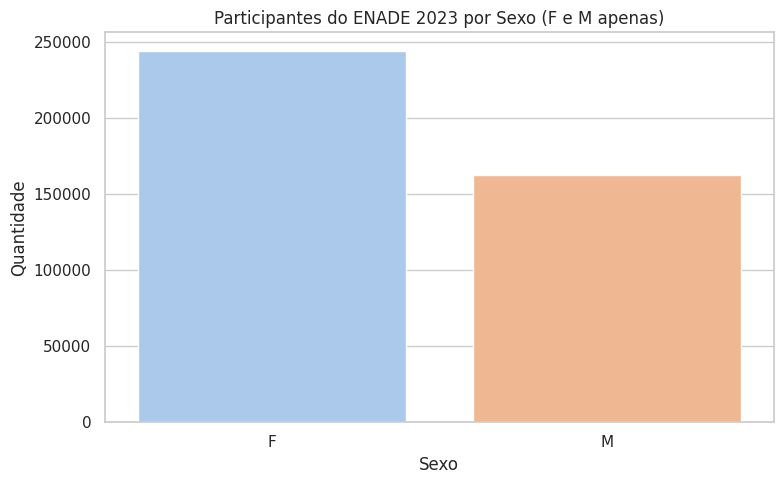

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Filtra  F e M
df_sexo_valido = enade5[enade5['TP_SEXO'].isin(['F', 'M'])]

# Conta a quantidade de cada sexo
df_sexo = df_sexo_valido['TP_SEXO'].value_counts().reset_index()
df_sexo.columns = ['Sexo', 'Quantidade']

# o gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(data=df_sexo, x='Sexo', y='Quantidade', palette='pastel')

plt.title('Participantes do ENADE 2023 por Sexo (F e M apenas)')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

In [71]:
enade['DESC_PUBLICA'] = ""
enade.loc[
    enade.CO_CATEGAD.isin([4, 5]),
    "DESC_PUBLICA"
 ] ="Privado"

In [72]:
enade.loc[
    enade.CO_CATEGAD.isin([1, 2, 3]),
    "DESC_PUBLICA"
] ="Público"

In [ ]:
enade.DESC_PUBLICA.value_counts()

,count
DESC_PUBLICA,
Privado,273596
Público,100005
,32693


In [73]:
enade.DESC_PUBLICA.value_counts() / enade.shape[0]

,count
DESC_PUBLICA,
Privado,0.673394
Público,0.246139
,0.080466


/tmp/ipython-input-74-1866294914.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_publica, x='Tipo_Instituicao', y='Quantidade', palette='pastel')


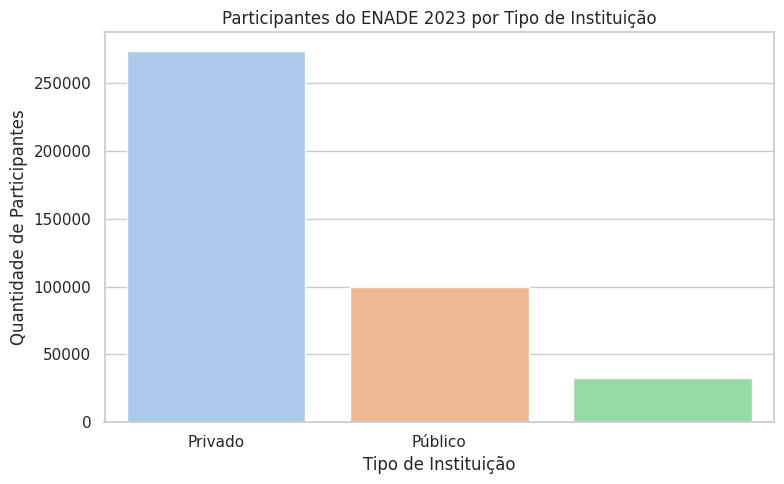

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das categorias
df_publica = enade['DESC_PUBLICA'].value_counts(dropna=False).reset_index()
df_publica.columns = ['Tipo_Instituicao', 'Quantidade']

# tratamento para mostrar onde estiver vazio
df_publica['Tipo_Instituicao'] = df_publica['Tipo_Instituicao'].fillna('Não informado')

# Gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(data=df_publica, x='Tipo_Instituicao', y='Quantidade', palette='pastel')

plt.title('Participantes do ENADE 2023 por Tipo de Instituição')
plt.xlabel('Tipo de Instituição')
plt.ylabel('Quantidade de Participantes')
plt.tight_layout()
plt.show()


In [75]:
# Transformar modalidade
enade8["CO_MODALIDADE"] = enade.CO_MODALIDADE.replace({
    0 : 'EAD',
    1 : 'Presencial'
})

In [ ]:
enade.CO_MODALIDADE.value_counts()

,count
CO_MODALIDADE,
1,340861
0,65433


/tmp/ipython-input-76-1419038219.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_modalidade, x='Modalidade', y='Quantidade', palette='pastel')


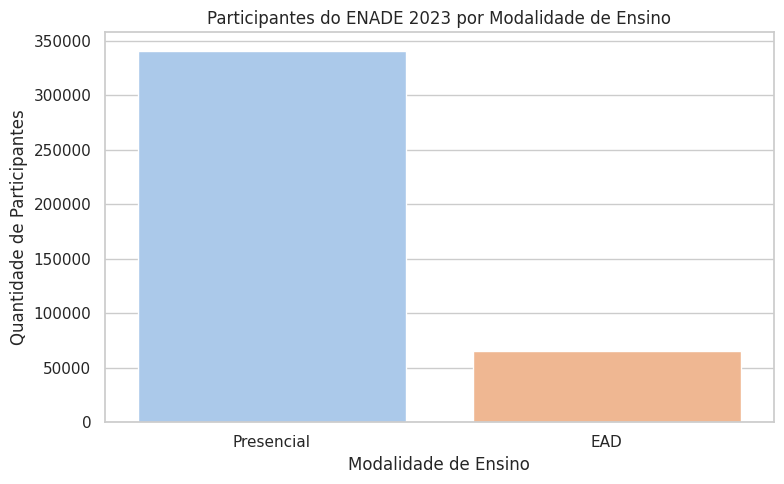

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das categorias
df_modalidade = enade8['CO_MODALIDADE'].value_counts().reset_index()
df_modalidade.columns = ['Modalidade', 'Quantidade']

# Grafico
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(data=df_modalidade, x='Modalidade', y='Quantidade', palette='pastel')

plt.title('Participantes do ENADE 2023 por Modalidade de Ensino')
plt.xlabel('Modalidade de Ensino')
plt.ylabel('Quantidade de Participantes')
plt.tight_layout()
plt.show()


In [77]:

enade8.QE_I02.value_counts()

,count
QE_I02,
A,201228
D,123007
B,30510
C,7338
F,4586
E,1057


In [ ]:
#Transformando cor
enade["DESC_COR"] = enade8.QE_I02.replace({
    "A": "Branca",
    "B": "Preta",
    "C": "Amarela",
    "D": "Parda",
    "E": "Indígena",
    "F": pd.NA

})

In [ ]:
dict(enade.DESC_COR.value_counts())

{'Branca': np.int64(201228),
 'Parda': np.int64(123007),
 'Preta': np.int64(30510),
 'Amarela': np.int64(7338),
 'Indígena': np.int64(1057)}

In [79]:
enade6 = pd.read_csv(
    "./DADOS/microdados2023_arq6.txt",
    sep=';', decimal=','
)

In [ ]:
print(enade6.columns)


Index(['NU_ANO', 'CO_CURSO', 'NU_IDADE'], dtype='object')


In [80]:
enade6.head()


,NU_ANO,CO_CURSO,NU_IDADE
0,2023,1439544,17
1,2023,1439544,18
2,2023,1441190,18
3,2023,1366207,18
4,2023,1404803,18


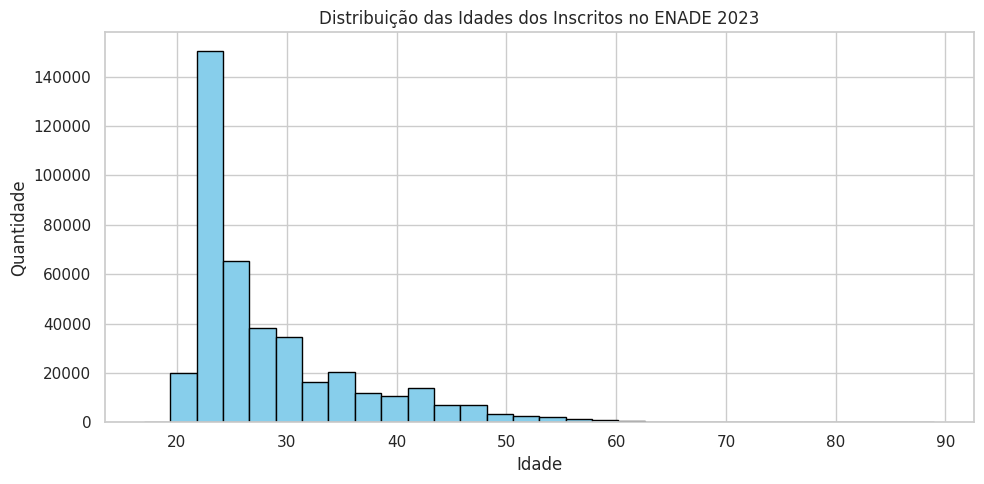

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
enade6['NU_IDADE'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuição das Idades dos Inscritos no ENADE 2023')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.grid(True)
plt.tight_layout()
plt.show()


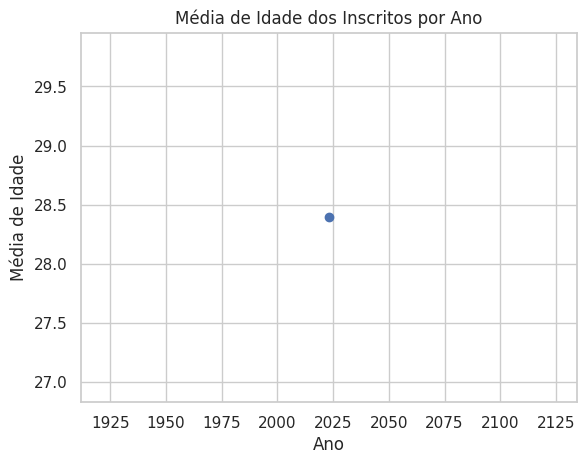

In [82]:
media_idade_ano = enade6.groupby('NU_ANO')['NU_IDADE'].mean()
media_idade_ano.plot(marker='o')
plt.title('Média de Idade dos Inscritos por Ano')
plt.xlabel('Ano')
plt.ylabel('Média de Idade')
plt.grid(True)
plt.show()


In [85]:
# Carregar para análise
enade1 = pd.read_csv('./DADOS/microdados2023_arq1.txt', sep=';', decimal=',',
                     usecols=['NU_ANO', 'CO_CURSO', 'CO_MODALIDADE', 'CO_CATEGAD'], nrows=10000)

enade6 = pd.read_csv('./DADOS/microdados2023_arq6.txt', sep=';', decimal=',',
                     usecols=['NU_ANO', 'CO_CURSO', 'NU_IDADE'], nrows=10000)

# Unir os dois arquivos
df = enade6.merge(enade1, on=['NU_ANO', 'CO_CURSO'], how='left')

#  códigos para nomes
df['MODALIDADE'] = df['CO_MODALIDADE'].replace({0: 'EAD', 1: 'Presencial'})
df['TIPO_IES'] = df['CO_CATEGAD'].map({
    1: 'Pública',
    2: 'Pública',
    3: 'Pública',
    4: 'Privada',
    5: 'Privada'
})

# Calcular média de idade por modalidade
print("Média de idade por modalidade:")
print(df.groupby('MODALIDADE')['NU_IDADE'].mean())

# Calcular média de idade por tipo de instituição
print("\nMédia de idade por tipo de instituição:")
print(df.groupby('TIPO_IES')['NU_IDADE'].mean())


Média de idade por modalidade:
MODALIDADE
Presencial    20.957685
Name: NU_IDADE, dtype: float64

Média de idade por tipo de instituição:
TIPO_IES
Privada    21.000000
Pública    20.941537
Name: NU_IDADE, dtype: float64
